In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from pathlib import Path

# Project folder
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data" / "processed"
REPORT_DIR = PROJECT_DIR / "reports" / "charts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", DATA_DIR)
print("Charts directory:", REPORT_DIR)

Project directory: C:\Users\anush\Downloads\mutual_fund_analytics
Processed data directory: C:\Users\anush\Downloads\mutual_fund_analytics\data\processed
Charts directory: C:\Users\anush\Downloads\mutual_fund_analytics\reports\charts


In [2]:
print("Processed CSV files:\n")

for file in sorted(DATA_DIR.glob("*.csv")):
    print(file.name)

Processed CSV files:

01_fund_master_clean.csv
02_nav_history_clean.csv
03_aum_by_fund_house_clean.csv
04_monthly_sip_inflows_clean.csv
05_category_inflows_clean.csv
06_industry_folio_count_clean.csv
07_scheme_performance_clean.csv
08_investor_transactions_clean.csv
09_portfolio_holdings_clean.csv
10_benchmark_indices_clean.csv


In [3]:
# Find NAV history and fund master files automatically

files = list(DATA_DIR.glob("*.csv"))

nav_file = next(
    f for f in files
    if "nav_history" in f.name.lower()
)

fund_file = next(
    f for f in files
    if "fund_master" in f.name.lower()
)

print("NAV file:", nav_file.name)
print("Fund master file:", fund_file.name)

# Load datasets
nav = pd.read_csv(nav_file)
fund_master = pd.read_csv(fund_file)

print("\nNAV shape:", nav.shape)
print("Fund Master shape:", fund_master.shape)

print("\nNAV columns:")
print(nav.columns.tolist())

print("\nFund Master columns:")
print(fund_master.columns.tolist())

NAV file: 02_nav_history_clean.csv
Fund master file: 01_fund_master_clean.csv

NAV shape: (64320, 3)
Fund Master shape: (40, 15)

NAV columns:
['amfi_code', 'date', 'nav']

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [4]:
# Prepare NAV data

nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.dropna(
    subset=["amfi_code", "date", "nav"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Number of schemes:", nav["amfi_code"].nunique())
print("Date range:", nav["date"].min(), "to", nav["date"].max())
print("NAV rows:", len(nav))

Number of schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
NAV rows: 64320


In [5]:
# Calculate daily returns for all 40 schemes
# daily_return = NAV(t) / NAV(t-1) - 1

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change(fill_method=None)
)

print("Daily returns calculated!")

print("\nDaily return summary:")
print(nav["daily_return"].describe())

print("\nSchemes:", nav["amfi_code"].nunique())

display(
    nav[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)

Daily returns calculated!

Daily return summary:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Schemes: 40


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-08,515.1639,0.000000
6,100016,2022-01-09,515.1639,0.000000
7,100016,2022-01-10,510.7136,-0.008639
8,100016,2022-01-11,513.5542,0.005562
9,100016,2022-01-12,512.3195,-0.002404


In [6]:
# Validate daily return distribution

return_stats = nav["daily_return"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)

print("Daily Return Distribution:")
print(return_stats)

# Check extreme daily movements
extreme_returns = nav[
    nav["daily_return"].abs() > 0.10
]

print("\nNumber of daily returns above +/-10%:")
print(len(extreme_returns))

if len(extreme_returns) > 0:
    display(
        extreme_returns[
            ["amfi_code", "date", "nav", "daily_return"]
        ].head(20)
    )

Daily Return Distribution:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
1%          -0.023781
5%          -0.014102
50%          0.000000
95%          0.015711
99%          0.025742
max          0.064713
Name: daily_return, dtype: float64

Number of daily returns above +/-10%:
0


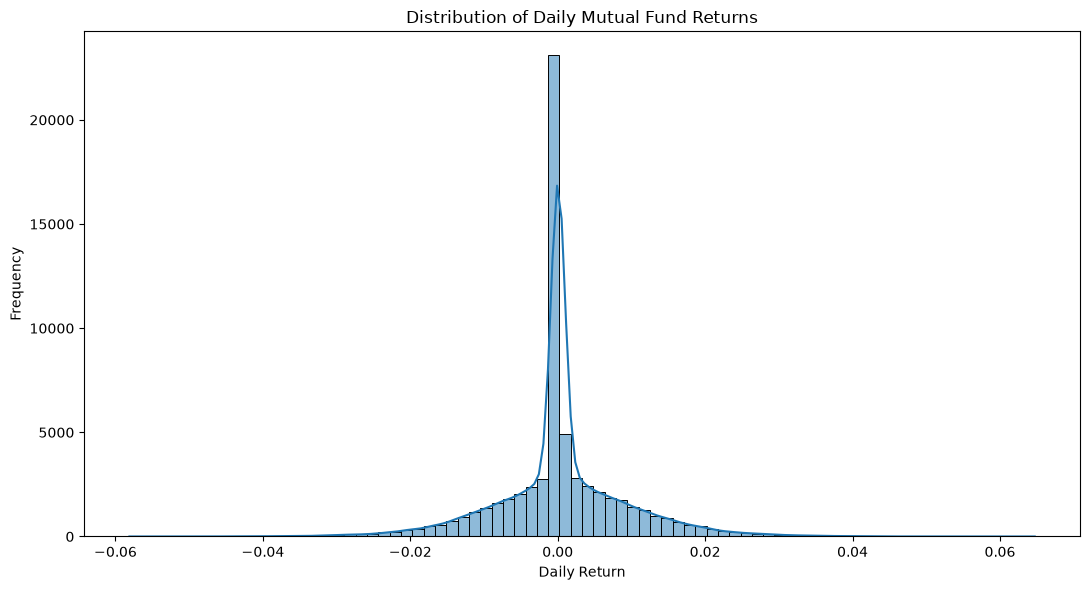

Daily return distribution chart exported successfully!


In [7]:
# Daily Return Distribution Histogram

plt.figure(figsize=(11, 6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "17_daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Daily return distribution chart exported successfully!")

In [8]:
# CAGR calculation function

def calculate_cagr(group, years):
    group = group.sort_values("date").copy()

    end_row = group.iloc[-1]
    end_date = end_row["date"]
    end_nav = end_row["nav"]

    target_date = end_date - pd.DateOffset(years=years)

    eligible = group[
        group["date"] <= target_date
    ]

    if eligible.empty:
        return np.nan

    start_row = eligible.iloc[-1]

    start_date = start_row["date"]
    start_nav = start_row["nav"]

    actual_years = (
        (end_date - start_date).days / 365.25
    )

    if start_nav <= 0 or actual_years <= 0:
        return np.nan

    return (
        (end_nav / start_nav) ** (1 / actual_years)
        - 1
    )


cagr_results = []

for code, group in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

print("CAGR calculated for all schemes.")

display(cagr_df.head(10))

CAGR calculated for all schemes.


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN
5,101208,0.072418,0.063143,NaN
6,102885,0.202229,0.196624,NaN
7,102886,-0.168080,-0.007672,NaN
8,102887,0.135930,0.255497,NaN
9,118632,0.340079,0.226466,NaN


In [9]:
# Add fund names to CAGR comparison

name_column = "scheme_name"

cagr_comparison = cagr_df.merge(
    fund_master[
        ["amfi_code", name_column]
    ],
    on="amfi_code",
    how="left"
)

for col in [
    "cagr_1yr",
    "cagr_3yr",
    "cagr_5yr"
]:
    cagr_comparison[col] = (
        cagr_comparison[col] * 100
    )

cagr_comparison = cagr_comparison.sort_values(
    "cagr_3yr",
    ascending=False
)

display(cagr_comparison)

print(
    "Funds in CAGR table:",
    len(cagr_comparison)
)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
16,119094,22.277897,35.102528,NaN,Axis Midcap Fund - Regular - Growth
34,148567,20.375957,33.991970,NaN,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,13.073788,32.478927,NaN,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,53.277195,32.433971,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,29.627681,31.769243,NaN,ICICI Pru Midcap Fund - Regular - Growth
19,119551,60.489297,30.448613,NaN,SBI Bluechip Fund - Regular Plan - Growth
30,120843,26.677584,29.575111,NaN,Kotak Flexicap Fund - Regular - Growth
36,148569,39.783803,29.171358,NaN,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,47.963794,28.960211,NaN,ABSL Frontline Equity Fund - Regular - Growth
39,149324,65.195466,26.993503,NaN,DSP Small Cap Fund - Regular - Growth


Funds in CAGR table: 40


In [10]:
# SHARPE RATIO

RF_ANNUAL = 0.065
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
rf_daily = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1 and returns.std() != 0:

        sharpe = (
            (returns.mean() - rf_daily)
            / returns.std()
            * np.sqrt(TRADING_DAYS)
        )

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

print("Sharpe ratios calculated:", len(sharpe_df))

display(
    sharpe_df.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(10)
)

Sharpe ratios calculated: 40


,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.085000,1.0
30,120843,0.980555,2.0
36,148569,0.932527,3.0
25,120505,0.895608,4.0
19,119551,0.878314,5.0
38,149323,0.846314,6.0
2,100033,0.820853,7.0
9,118632,0.775693,8.0
16,119094,0.742829,9.0
3,101206,0.733767,10.0


In [11]:
# SORTINO RATIO

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside_returns = returns[
        returns < 0
    ]

    if (
        len(returns) > 1
        and len(downside_returns) > 1
        and downside_returns.std() != 0
    ):

        sortino = (
            (returns.mean() - rf_daily)
            / downside_returns.std()
            * np.sqrt(TRADING_DAYS)
        )

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
)

print("Sortino ratios calculated:", len(sortino_df))

display(
    sortino_df.sort_values(
        "sortino_ratio",
        ascending=False
    ).head(10)
)

Sortino ratios calculated: 40


,amfi_code,sortino_ratio,sortino_rank
34,148567,1.514151,1.0
30,120843,1.502478,2.0
36,148569,1.372658,3.0
19,119551,1.317488,4.0
25,120505,1.303826,5.0
38,149323,1.186621,6.0
2,100033,1.162033,7.0
9,118632,1.123268,8.0
24,120504,1.088663,9.0
3,101206,1.088168,10.0


In [12]:
# Combine performance metrics

performance_metrics = (
    cagr_comparison
    .merge(
        sharpe_df,
        on="amfi_code",
        how="left"
    )
    .merge(
        sortino_df,
        on="amfi_code",
        how="left"
    )
)

performance_metrics = performance_metrics.sort_values(
    "sharpe_ratio",
    ascending=False
)

display(
    performance_metrics[
        [
            "amfi_code",
            "scheme_name",
            "cagr_1yr",
            "cagr_3yr",
            "cagr_5yr",
            "sharpe_ratio",
            "sharpe_rank",
            "sortino_ratio",
            "sortino_rank"
        ]
    ]
)

print(
    "Total funds ranked:",
    len(performance_metrics)
)

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.375957,33.991970,NaN,1.085000,1.0,1.514151,1.0
6,120843,Kotak Flexicap Fund - Regular - Growth,26.677584,29.575111,NaN,0.980555,2.0,1.502478,2.0
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.783803,29.171358,NaN,0.932527,3.0,1.372658,3.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.627681,31.769243,NaN,0.895608,4.0,1.303826,5.0
5,119551,SBI Bluechip Fund - Regular Plan - Growth,60.489297,30.448613,NaN,0.878314,5.0,1.317488,4.0
10,149323,DSP Midcap Fund - Regular - Growth,21.497414,26.863104,NaN,0.846314,6.0,1.186621,6.0
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.277195,32.433971,NaN,0.820853,7.0,1.162033,7.0
13,118632,Nippon India Large Cap Fund - Regular - Growth,34.007896,22.646647,NaN,0.775693,8.0,1.123268,8.0
0,119094,Axis Midcap Fund - Regular - Growth,22.277897,35.102528,NaN,0.742829,9.0,1.073027,12.0
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.963794,28.960211,NaN,0.733767,10.0,1.088168,10.0


Total funds ranked: 40


In [13]:
# Find benchmark file automatically

benchmark_file = next(
    f for f in DATA_DIR.glob("*.csv")
    if "benchmark" in f.name.lower()
)

benchmark = pd.read_csv(benchmark_file)

print("Benchmark file:", benchmark_file.name)
print("Benchmark shape:", benchmark.shape)

print("\nColumns:")
print(benchmark.columns.tolist())

print("\nSample:")
display(benchmark.head())

print("\nUnique benchmark/index names:")
for col in benchmark.columns:
    if benchmark[col].dtype == "object":
        print(col, ":", benchmark[col].unique()[:20])

Benchmark file: 10_benchmark_indices_clean.csv
Benchmark shape: (8050, 3)

Columns:
['date', 'index_name', 'close_value']

Sample:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15



Unique benchmark/index names:
date : ['2022-01-03' '2022-01-04' '2022-01-05' '2022-01-06' '2022-01-07'
 '2022-01-10' '2022-01-11' '2022-01-12' '2022-01-13' '2022-01-14'
 '2022-01-17' '2022-01-18' '2022-01-19' '2022-01-20' '2022-01-21'
 '2022-01-24' '2022-01-25' '2022-01-26' '2022-01-27' '2022-01-28']
index_name : ['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [14]:
# Prepare benchmark data

benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    errors="coerce"
)

# Detect numeric value column
excluded = {"date", "index_name"}

value_columns = [
    col for col in benchmark.columns
    if col not in excluded
]

print("Possible benchmark value columns:", value_columns)

# Use first numeric-compatible column
benchmark_value_col = None

for col in value_columns:
    converted = pd.to_numeric(
        benchmark[col],
        errors="coerce"
    )

    if converted.notna().sum() > 0:
        benchmark_value_col = col
        benchmark[col] = converted
        break

print("Using benchmark value column:", benchmark_value_col)

# NIFTY 100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100[benchmark_value_col]
    .pct_change(fill_method=None)
)

display(nifty100.head())

print("NIFTY100 observations:", len(nifty100))

Possible benchmark value columns: ['close_value']
Using benchmark value column: close_value


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


NIFTY100 observations: 1150


In [15]:
# ALPHA AND BETA USING NIFTY 100

alpha_beta_results = []

for code, fund_data in nav.groupby("amfi_code"):

    fund_returns = fund_data[
        ["date", "daily_return"]
    ].dropna().copy()

    merged = fund_returns.merge(
        nifty100[
            ["date", "benchmark_return"]
        ].dropna(),
        on="date",
        how="inner"
    )

    if len(merged) >= 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        # Annualised alpha
        alpha = regression.intercept * 252

        alpha_beta_results.append({
            "amfi_code": code,
            "alpha": alpha,
            "beta": beta,
            "r_squared": regression.rvalue ** 2,
            "p_value": regression.pvalue,
            "observations": len(merged)
        })

    else:

        alpha_beta_results.append({
            "amfi_code": code,
            "alpha": np.nan,
            "beta": np.nan,
            "r_squared": np.nan,
            "p_value": np.nan,
            "observations": len(merged)
        })


alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

print(
    "Funds analysed:",
    len(alpha_beta_df)
)

display(
    alpha_beta_df.sort_values(
        "alpha",
        ascending=False
    ).head(10)
)

Funds analysed: 40


,amfi_code,alpha,beta,r_squared,p_value,observations
21,119598,0.303370,-0.023196,1.414258e-04,0.687179,1149
39,149324,0.300579,0.011455,3.532991e-05,0.840494,1149
25,120505,0.292636,0.000549,1.345534e-07,0.990090,1149
36,148569,0.282704,0.018134,1.748889e-04,0.654295,1149
30,120843,0.273305,-0.022830,3.430543e-04,0.530528,1149
2,100033,0.271954,0.005104,1.206652e-05,0.906369,1149
34,148567,0.269838,0.023684,4.625437e-04,0.466427,1149
38,149323,0.265986,-0.002523,3.357978e-06,0.950525,1149
16,119094,0.260767,-0.066265,1.936879e-03,0.135988,1149
19,119551,0.232010,-0.031751,8.869789e-04,0.313143,1149


In [16]:
# Add scheme names

alpha_beta_output = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Convert alpha to percentage for easier interpretation
alpha_beta_output["alpha_pct"] = (
    alpha_beta_output["alpha"] * 100
)

alpha_beta_output = alpha_beta_output[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "alpha_pct",
        "beta",
        "r_squared",
        "p_value",
        "observations"
    ]
]

alpha_beta_output = alpha_beta_output.sort_values(
    "alpha",
    ascending=False
)

display(alpha_beta_output.head(10))

# Required deliverable
alpha_beta_output.to_csv(
    DATA_DIR / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported successfully!")

,amfi_code,scheme_name,alpha,alpha_pct,beta,r_squared,p_value,observations
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,30.336965,-0.023196,1.414258e-04,0.687179,1149
39,149324,DSP Small Cap Fund - Regular - Growth,0.300579,30.057878,0.011455,3.532991e-05,0.840494,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,29.263583,0.000549,1.345534e-07,0.990090,1149
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,28.270368,0.018134,1.748889e-04,0.654295,1149
30,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,27.330465,-0.022830,3.430543e-04,0.530528,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,27.195355,0.005104,1.206652e-05,0.906369,1149
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,26.983751,0.023684,4.625437e-04,0.466427,1149
38,149323,DSP Midcap Fund - Regular - Growth,0.265986,26.598578,-0.002523,3.357978e-06,0.950525,1149
16,119094,Axis Midcap Fund - Regular - Growth,0.260767,26.076669,-0.066265,1.936879e-03,0.135988,1149
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,23.201007,-0.031751,8.869789e-04,0.313143,1149


alpha_beta.csv exported successfully!


In [17]:
print("Alpha/Beta rows:", len(alpha_beta_output))
print("Missing Alpha:", alpha_beta_output["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_output["beta"].isna().sum())

print("\nBeta summary:")
print(alpha_beta_output["beta"].describe())

print("\nAlpha (%) summary:")
print(alpha_beta_output["alpha_pct"].describe())

Alpha/Beta rows: 40
Missing Alpha: 0
Missing Beta: 0

Beta summary:
count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

Alpha (%) summary:
count    40.000000
mean     15.908530
std       8.752842
min       2.896940
25%       6.861200
50%      16.232555
75%      22.172300
max      30.336965
Name: alpha_pct, dtype: float64


In [18]:
# MAXIMUM DRAWDOWN + WORST DRAWDOWN PERIOD

drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Worst drawdown point
    trough_idx = group["drawdown"].idxmin()
    trough_row = group.loc[trough_idx]

    trough_date = trough_row["date"]
    max_drawdown = trough_row["drawdown"]

    # Peak before the trough
    before_trough = group[
        group["date"] <= trough_date
    ]

    peak_idx = before_trough["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown": max_drawdown,
        "max_drawdown_pct": max_drawdown * 100,
        "drawdown_start": peak_date,
        "drawdown_trough": trough_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

print(
    "Drawdown calculated for:",
    len(drawdown_df),
    "funds"
)

display(
    drawdown_df.sort_values(
        "max_drawdown"
    ).head(10)
)

Drawdown calculated for: 40 funds


,amfi_code,max_drawdown,max_drawdown_pct,drawdown_start,drawdown_trough
22,119599,-0.525742,-52.574221,2023-01-17,2025-10-28
17,119095,-0.516778,-51.677754,2025-05-22,2026-05-11
4,101207,-0.354469,-35.446916,2024-11-21,2026-05-11
39,149324,-0.311719,-31.171900,2024-05-03,2025-01-03
21,119598,-0.287060,-28.706006,2024-08-28,2025-05-14
7,102886,-0.280011,-28.001124,2025-01-07,2026-04-27
0,100016,-0.247344,-24.734441,2022-03-30,2022-09-15
29,120842,-0.240035,-24.003511,2023-11-09,2024-10-17
11,118634,-0.233449,-23.344886,2025-04-09,2026-02-20
15,119093,-0.217514,-21.751396,2022-02-24,2023-05-22


In [19]:
drawdown_output = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

drawdown_output = drawdown_output[
    [
        "amfi_code",
        "scheme_name",
        "max_drawdown",
        "max_drawdown_pct",
        "drawdown_start",
        "drawdown_trough"
    ]
]

print("Worst 10 drawdowns:")

display(
    drawdown_output.sort_values(
        "max_drawdown"
    ).head(10)
)

Worst 10 drawdowns:


,amfi_code,scheme_name,max_drawdown,max_drawdown_pct,drawdown_start,drawdown_trough
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,-52.574221,2023-01-17,2025-10-28
17,119095,Axis Small Cap Fund - Regular - Growth,-0.516778,-51.677754,2025-05-22,2026-05-11
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,-35.446916,2024-11-21,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,-0.311719,-31.171900,2024-05-03,2025-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,-28.706006,2024-08-28,2025-05-14
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.280011,-28.001124,2025-01-07,2026-04-27
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,-24.734441,2022-03-30,2022-09-15
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,-24.003511,2023-11-09,2024-10-17
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.233449,-23.344886,2025-04-09,2026-02-20
15,119093,Axis Bluechip Fund - Direct - Growth,-0.217514,-21.751396,2022-02-24,2023-05-22


In [20]:
print("Total funds:", len(drawdown_output))

print(
    "\nAverage Maximum Drawdown:",
    round(
        drawdown_output["max_drawdown_pct"].mean(),
        2
    ),
    "%"
)

worst = drawdown_output.loc[
    drawdown_output["max_drawdown"].idxmin()
]

print("\nWorst fund:")
print(worst["scheme_name"])

print(
    "Maximum Drawdown:",
    round(worst["max_drawdown_pct"], 2),
    "%"
)

print(
    "Drawdown period:",
    worst["drawdown_start"].date(),
    "to",
    worst["drawdown_trough"].date()
)

Total funds: 40

Average Maximum Drawdown: -17.87 %

Worst fund:
SBI Small Cap Fund - Direct Plan - Growth
Maximum Drawdown: -52.57 %
Drawdown period: 2023-01-17 to 2025-10-28


In [21]:
# Load scheme performance dataset

performance_file = next(
    f for f in DATA_DIR.glob("*.csv")
    if "scheme_performance" in f.name.lower()
)

scheme_performance = pd.read_csv(performance_file)

print("Performance file:", performance_file.name)
print("Columns:")
print(scheme_performance.columns.tolist())

print("\nExpense ratio summary:")
print(scheme_performance["expense_ratio_pct"].describe())

Performance file: 07_scheme_performance_clean.csv
Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_anomaly_flag', 'expense_ratio_anomaly_flag']

Expense ratio summary:
count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64


In [22]:
# Build Fund Scorecard base table

scorecard = (
    cagr_df[["amfi_code", "cagr_3yr"]]
    .merge(
        sharpe_df[["amfi_code", "sharpe_ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[["amfi_code", "alpha"]],
        on="amfi_code"
    )
    .merge(
        drawdown_df[["amfi_code", "max_drawdown"]],
        on="amfi_code"
    )
    .merge(
        scheme_performance[
            ["amfi_code", "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
    .merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code",
        how="left"
    )
)

print("Funds in scorecard:", len(scorecard))

display(scorecard.head())

Funds in scorecard: 40


,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,scheme_name
0,100016,0.012924,-0.304619,0.037476,-0.247344,1.55,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.039155,-0.978884,0.042818,-0.043083,0.56,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.324340,0.820853,0.271954,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.289602,0.733767,0.213998,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.041515,0.061866,0.108971,-0.354469,1.53,ABSL Small Cap Fund - Regular - Growth


In [23]:
# FUND SCORECARD (0-100)

N = len(scorecard)

# Higher is better
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False, method="average")
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, method="average")
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, method="average")
)

# Lower expense ratio is better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, method="average")
)

# Max drawdown closer to zero is better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, method="average")
)

# Convert rank to 0-100 score
def rank_to_score(rank, total):
    if total <= 1:
        return 100

    return (
        (total - rank) /
        (total - 1)
    ) * 100


scorecard["return_score"] = rank_to_score(
    scorecard["return_rank"], N
)

scorecard["sharpe_score"] = rank_to_score(
    scorecard["sharpe_rank"], N
)

scorecard["alpha_score"] = rank_to_score(
    scorecard["alpha_rank"], N
)

scorecard["expense_score"] = rank_to_score(
    scorecard["expense_rank"], N
)

scorecard["drawdown_score"] = rank_to_score(
    scorecard["drawdown_rank"], N
)

# Composite score
scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

scorecard["overall_rank"] = (
    scorecard["fund_score"]
    .rank(
        ascending=False,
        method="min"
    )
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

print("Fund Scorecard calculated!")

display(
    scorecard[
        [
            "overall_rank",
            "scheme_name",
            "cagr_3yr",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown",
            "fund_score"
        ]
    ].head(10)
)

Fund Scorecard calculated!


,overall_rank,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
34,1.0,Mirae Asset Large Cap Fund - Regular - Growth,0.339920,1.085000,0.269838,1.46,-0.112657,85.897436
25,2.0,ICICI Pru Midcap Fund - Regular - Growth,0.317692,0.895608,0.292636,1.36,-0.181885,82.435897
30,3.0,Kotak Flexicap Fund - Regular - Growth,0.295751,0.980555,0.273305,1.45,-0.129740,81.538462
2,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324340,0.820853,0.271954,1.38,-0.162172,80.256410
24,5.0,ICICI Pru Bluechip Fund - Direct - Growth,0.324789,0.731273,0.211948,0.80,-0.125883,78.846154
16,6.0,Axis Midcap Fund - Regular - Growth,0.351025,0.742829,0.260767,1.38,-0.209609,77.692308
19,7.0,SBI Bluechip Fund - Regular Plan - Growth,0.304486,0.878314,0.232010,1.54,-0.150124,73.525641
36,8.0,Mirae Asset Tax Saver Fund - Regular - Growth,0.291714,0.932527,0.282704,1.60,-0.163967,73.012821
21,9.0,SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.721173,0.303370,1.43,-0.287060,67.179487
3,10.0,ABSL Frontline Equity Fund - Regular - Growth,0.289602,0.733767,0.213998,1.60,-0.112916,66.730769


In [24]:
scorecard.to_csv(
    DATA_DIR / "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv exported successfully!")
print("Total funds:", len(scorecard))

print("\nTop 5 funds:")
display(
    scorecard[
        [
            "overall_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ].head(5)
)

fund_scorecard.csv exported successfully!
Total funds: 40

Top 5 funds:


,overall_rank,amfi_code,scheme_name,fund_score
34,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
25,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,82.435897
30,3.0,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
2,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.256410
24,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,78.846154


In [25]:
# Prepare NIFTY50 and NIFTY100

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy().sort_values("date")

nifty100_compare = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy().sort_values("date")

# Keep only last 3 years based on available NAV data
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nifty50 = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= end_date)
].copy()

nifty100_compare = nifty100_compare[
    (nifty100_compare["date"] >= start_date) &
    (nifty100_compare["date"] <= end_date)
].copy()

# Daily benchmark returns
nifty50["daily_return"] = (
    nifty50[benchmark_value_col]
    .pct_change(fill_method=None)
)

nifty100_compare["daily_return"] = (
    nifty100_compare[benchmark_value_col]
    .pct_change(fill_method=None)
)

print("Comparison period:")
print(start_date.date(), "to", end_date.date())

print("NIFTY50 rows:", len(nifty50))
print("NIFTY100 rows:", len(nifty100_compare))

Comparison period:
2023-05-29 to 2026-05-29
NIFTY50 rows: 785
NIFTY100 rows: 785


In [26]:
# Select Top 5 Funds from Fund Scorecard

top5 = scorecard.head(5).copy()

top5_codes = top5["amfi_code"].tolist()

print("Top 5 Funds:")

display(
    top5[
        [
            "overall_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ]
)

Top 5 Funds:


,overall_rank,amfi_code,scheme_name,fund_score
34,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
25,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,82.435897
30,3.0,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
2,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.256410
24,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,78.846154


In [27]:
# Create normalized 3-year performance series

comparison_data = {}

for code in top5_codes:

    fund = nav[
        (nav["amfi_code"] == code) &
        (nav["date"] >= start_date) &
        (nav["date"] <= end_date)
    ].copy().sort_values("date")

    if not fund.empty:

        fund["normalized"] = (
            fund["nav"] /
            fund["nav"].iloc[0]
        ) * 100

        scheme = fund_master.loc[
            fund_master["amfi_code"] == code,
            "scheme_name"
        ].iloc[0]

        comparison_data[scheme] = fund[
            ["date", "normalized"]
        ]


# Normalize NIFTY50

nifty50["normalized"] = (
    nifty50[benchmark_value_col] /
    nifty50[benchmark_value_col].iloc[0]
) * 100


# Normalize NIFTY100

nifty100_compare["normalized"] = (
    nifty100_compare[benchmark_value_col] /
    nifty100_compare[benchmark_value_col].iloc[0]
) * 100

print("Normalized series prepared successfully!")

Normalized series prepared successfully!


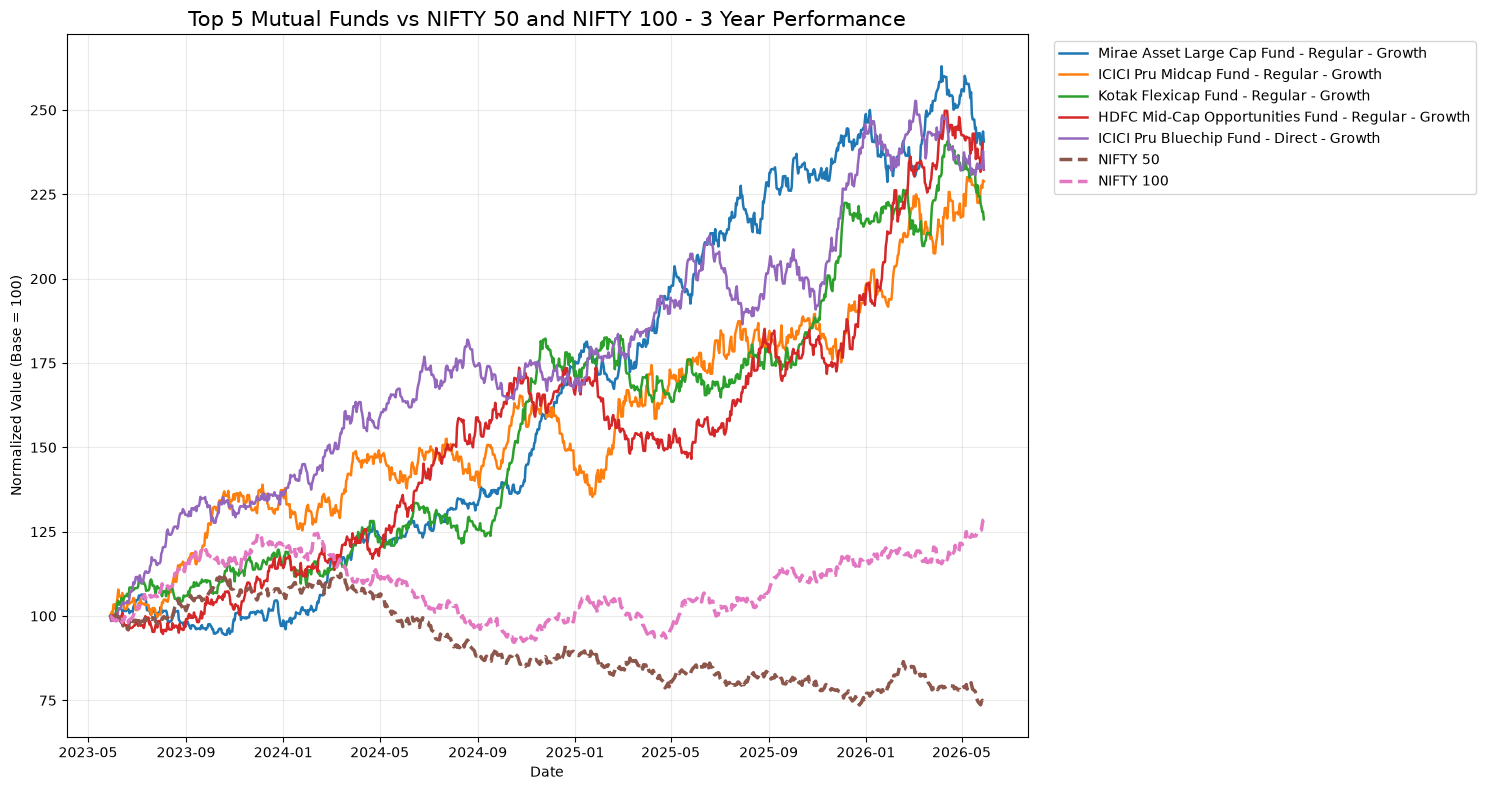

benchmark_comparison.png exported successfully!


In [28]:
# BENCHMARK COMPARISON CHART

plt.figure(figsize=(15, 8))

for scheme, data in comparison_data.items():

    plt.plot(
        data["date"],
        data["normalized"],
        label=scheme,
        linewidth=1.8
    )


plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="NIFTY 50",
    linewidth=2.5,
    linestyle="--"
)

plt.plot(
    nifty100_compare["date"],
    nifty100_compare["normalized"],
    label="NIFTY 100",
    linewidth=2.5,
    linestyle="--"
)

plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 - 3 Year Performance",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png exported successfully!")

In [29]:
# TRACKING ERROR

tracking_results = []

for code in top5_codes:

    fund = nav[
        (nav["amfi_code"] == code) &
        (nav["date"] >= start_date) &
        (nav["date"] <= end_date)
    ][
        ["date", "daily_return"]
    ].dropna()

    scheme = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    # Against NIFTY50
    merged50 = fund.merge(
        nifty50[
            ["date", "daily_return"]
        ],
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    tracking50 = (
        (
            merged50["daily_return_fund"] -
            merged50["daily_return_benchmark"]
        ).std()
        * np.sqrt(252)
    )

    # Against NIFTY100
    merged100 = fund.merge(
        nifty100_compare[
            ["date", "daily_return"]
        ],
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    tracking100 = (
        (
            merged100["daily_return_fund"] -
            merged100["daily_return_benchmark"]
        ).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": code,
        "scheme_name": scheme,
        "tracking_error_nifty50": tracking50,
        "tracking_error_nifty100": tracking100
    })


tracking_error_df = pd.DataFrame(
    tracking_results
)

tracking_error_df[
    "tracking_error_nifty50_pct"
] = tracking_error_df[
    "tracking_error_nifty50"
] * 100

tracking_error_df[
    "tracking_error_nifty100_pct"
] = tracking_error_df[
    "tracking_error_nifty100"
] * 100


display(tracking_error_df)

print(
    "Tracking error calculated for:",
    len(tracking_error_df),
    "funds"
)

,amfi_code,scheme_name,tracking_error_nifty50,tracking_error_nifty100,tracking_error_nifty50_pct,tracking_error_nifty100_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.191868,0.187974,19.186766,18.797377
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.228447,0.232661,22.844692,23.266122
2,120843,Kotak Flexicap Fund - Regular - Growth,0.205067,0.206540,20.506700,20.653968
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228222,0.224976,22.822178,22.497629
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.188211,0.187299,18.821141,18.729904


Tracking error calculated for: 5 funds
